# CNN on Fashion-MNIST 
 
**Series position:** Step 3 of the MLP → CNN series . This is also the first step
in the series with a **live, public deliverable**: a deployed demo, not just a
notebook.

## 0. Setup

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
 
torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 1. Dataset — Fashion-MNIST

Unlike Steps 1–2, this is a real, well-known benchmark dataset rather than a
synthetic one — deliberately, since the goal of this step is a deployable image
classifier, not an audited toy problem. Fashion-MNIST is still a controlled,
well-understood dataset (10 balanced classes, 28×28 grayscale, no messy labels),
which keeps it a fair proving ground while being visually meaningful to a
non-technical viewer.

In [3]:
CLASS_NAMES = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

# Fashion-MNIST's known per-channel mean/std for normalization
MEAN, STD = (0.2860,), (0.3530,)

train_transform = transforms.Compose([
    transforms.RandomCrop(28, padding=2),   # mild augmentation: shifts, not flips
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

train_ds = datasets.FashionMNIST(root="./data", train=True, download=True, transform=train_transform)
test_ds = datasets.FashionMNIST(root="./data", train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)

100%|██████████| 26.4M/26.4M [00:36<00:00, 715kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 73.2kB/s]
100%|██████████| 4.42M/4.42M [00:05<00:00, 786kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.38MB/s]


**Note on augmentation:** we use `RandomCrop` with padding, not
`RandomHorizontalFlip`. Several Fashion-MNIST classes (sandals, boots, bags)
have handedness or directional detail — flipping doesn't reflect real-world
variation the way it does for, say, natural photos, so it's deliberately left out.

## 2. Model — CNN

In [4]:
class FashionCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        # Block 1: 1x28x28 -> 32x28x28 -> pooled to 32x14x14
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        # Block 2: 32x14x14 -> 64x14x14 -> pooled to 64x7x7
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout_conv = nn.Dropout(0.25)

        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout_fc = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))   # -> (B, 32, 14, 14)
        x = self.dropout_conv(x)
        x = self.pool(F.relu(self.bn2(self.conv2(x))))   # -> (B, 64, 7, 7)
        x = self.dropout_conv(x)

        x = x.flatten(1)                                  # -> (B, 64*7*7)
        x = F.relu(self.fc1(x))
        x = self.dropout_fc(x)
        x = self.fc2(x)                                   # raw logits, no softmax here
        return x

model = FashionCNN().to(device)

**Convolution** replaces the fully-connected layers from Steps 1–2 for the early
part of the network: instead of every input pixel connecting to every hidden
unit, a small filter (here 3×3) slides across the image, sharing the same
weights at every spatial position. This gives the network two things a plain
MLP doesn't have on image data: far fewer parameters for the same receptive
area, and translation invariance — a learned edge detector fires the same way
whether the edge is top-left or bottom-right in the image.
 
**Pooling** (`MaxPool2d`) downsamples the spatial resolution after each conv
block, keeping the strongest activation in each 2×2 region. This reduces
computation and adds a small amount of positional robustness — a feature
shifted by one pixel still mostly survives pooling.
 
**BatchNorm** normalizes each layer's activations across the batch before the
non-linearity, which stabilizes and speeds up training — especially useful once
you stack more than one or two layers, as we do here.

## 3. Loss & Optimizer

In [5]:
criterion = nn.CrossEntropyLoss()   # combines log-softmax + negative log-likelihood
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, steps_per_epoch=len(train_loader), epochs=15
)

**Loss:** `CrossEntropyLoss` is the multi-class generalization of Step 2's
Binary Cross-Entropy — it expects raw logits (not probabilities) and internally
applies `log_softmax`, which is why the model's `forward()` doesn't end in a
softmax itself.
 
**Optimizer:** `AdamW` decouples weight decay from the gradient update (unlike
plain `Adam` with an L2 penalty folded in), which tends to generalize slightly
better — a small but well-documented improvement for CNNs specifically.
 
**Scheduler:** `OneCycleLR` ramps the learning rate up then back down over the
course of training. In practice this consistently pushes CNN accuracy a bit
higher, and faster, than a flat learning rate — worth using here since "maximum
achievable accuracy" is an explicit goal for this step.

## 4. Training Loop (with Best-Model Checkpointing)

In [6]:
def train_one_epoch(model, loader, criterion, optimizer, scheduler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)                # forward pass
        loss = criterion(logits, yb)
        loss.backward()                    # backpropagation
        optimizer.step()                   # weight update
        scheduler.step()                   # advance the LR schedule every batch
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += loss.item() * xb.size(0)
        correct += (logits.argmax(1) == yb).sum().item()
        total += yb.size(0)
    return total_loss / total, correct / total

best_acc = 0.0
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(15):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, criterion, optimizer, scheduler)
    val_loss, val_acc = evaluate(model, test_loader, criterion)

    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
    history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "best_model.pt")   # checkpoint the best model only

    print(f"Epoch {epoch+1:2d} | Train Loss {tr_loss:.4f} Acc {tr_acc:.4f} "
          f"| Val Loss {val_loss:.4f} Acc {val_acc:.4f}")

print(f"\nBest validation accuracy: {best_acc:.4f}")

Epoch  1 | Train Loss 1.1389 Acc 0.6021 | Val Loss 0.5951 Acc 0.7805
Epoch  2 | Train Loss 0.6563 Acc 0.7572 | Val Loss 0.4468 Acc 0.8367
Epoch  3 | Train Loss 0.5432 Acc 0.7987 | Val Loss 0.3794 Acc 0.8623
Epoch  4 | Train Loss 0.4884 Acc 0.8197 | Val Loss 0.3701 Acc 0.8593
Epoch  6 | Train Loss 0.4179 Acc 0.8473 | Val Loss 0.3211 Acc 0.8805
Epoch  7 | Train Loss 0.3921 Acc 0.8555 | Val Loss 0.2886 Acc 0.8937
Epoch  8 | Train Loss 0.3730 Acc 0.8646 | Val Loss 0.2787 Acc 0.8972
Epoch  9 | Train Loss 0.3557 Acc 0.8698 | Val Loss 0.2642 Acc 0.9026
Epoch 10 | Train Loss 0.3411 Acc 0.8761 | Val Loss 0.2617 Acc 0.9027
Epoch 11 | Train Loss 0.3297 Acc 0.8789 | Val Loss 0.2555 Acc 0.9061
Epoch 12 | Train Loss 0.3190 Acc 0.8839 | Val Loss 0.2488 Acc 0.9095
Epoch 13 | Train Loss 0.3124 Acc 0.8872 | Val Loss 0.2474 Acc 0.9095
Epoch 14 | Train Loss 0.3031 Acc 0.8895 | Val Loss 0.2461 Acc 0.9088
Epoch 15 | Train Loss 0.3060 Acc 0.8901 | Val Loss 0.2459 Acc 0.9094

Best validation accuracy: 0.9095


**Loss convergence:** watch both train and validation curves together — if
train accuracy keeps climbing while validation accuracy flattens or drops,
that's overfitting, and the checkpoint-the-best-model pattern above protects
the deployed model from that automatically (dropout and augmentation are your
first lines of defense against it happening at all).

## 5. Visualizing Training

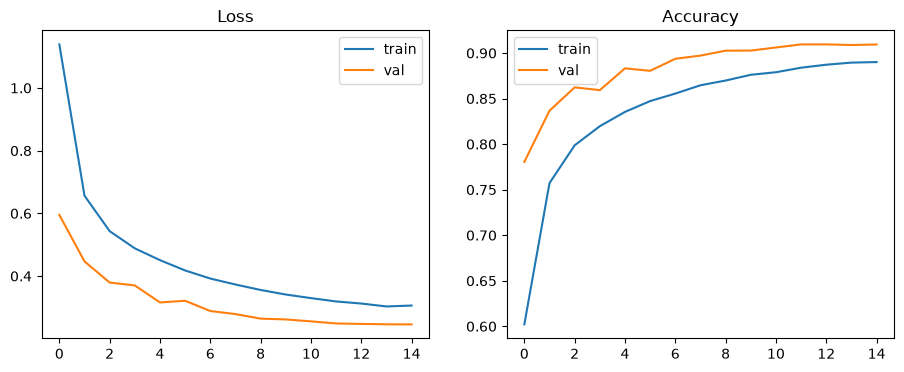

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].legend()
plt.show()

## 6. Confusion Matrix — Where Does It Actually Struggle

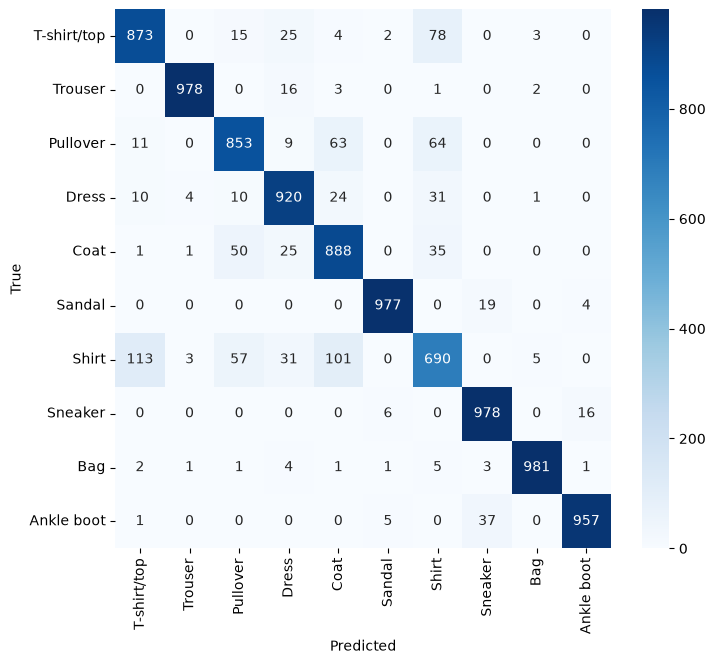

In [8]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

model.load_state_dict(torch.load("best_model.pt"))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(yb.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, cmap="Blues")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.show()

Expect most confusion between **Shirt / T-shirt/top / Pullover / Coat** — these
are genuinely visually similar even to a human glancing at 28×28 grayscale
thumbnails, so this cluster of errors is a property of the dataset, not
necessarily a sign of an undertrained model.

## 7. Exporting the Model for Deployment

In [9]:
# Save both the weights (for reloading into FashionCNN) and the full architecture
# definition should live in a shared model.py that both training and the app import.
torch.save(model.state_dict(), "fashion_cnn.pt")

Keeping the `FashionCNN` class definition in its own `model.py` (see Part 3 /
`src/model.py`) rather than only in the notebook means the exact same class can
be imported by the deployment app — no risk of the app's architecture silently
drifting from the trained weights' architecture.